In [3]:
import asyncio
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

from dhanhq import dhanhq
# from dhanhq.fulldepth import FullDepth

from dotenv import load_dotenv
import os

from data_from_dhan_util import DhanContext#, MarketRecorder, RingBuffer
from incremental_indexed import MarketRecorder, RingBuffer
from data_pull_bestprice import BestBidAskRecorder

In [4]:
from dhanhq import dhanhq
# from dhanhq import fulldepth

import websockets
import asyncio
import struct
from datetime import datetime
import json
import numpy as np
import pandas as pd
import copy
import os

import websockets
import asyncio
import struct
from datetime import datetime
import json


class FullDepth:
    # Constants
    """WebSocket URL for DhanHQ Live Market Feed"""
    depth_feed_wss = 'wss://depth-api-feed.dhan.co/twentydepth'

    """Constants for Exchange Segment"""
    NSE = 1
    NSE_FNO = 2

    """Constants for Request Code"""
    Depth_20 = 23

    def __init__(self, dhan_context, instruments):
        """Initializes the FullDepth instance with user credentials, instruments to subscribe, and callback functions."""
        self.client_id = dhan_context.get_client_id()
        self.access_token = dhan_context.get_access_token()
        self.instruments = instruments
        self.data = ""
        self._is_first_connect = True
        self.ws = None
        self.on_ticks = None
        self.loop = asyncio.get_event_loop()
        self.on_close = False

    def run_forever(self):
        """Starts the WebSocket connection and runs the event loop."""
        self.loop.run_until_complete(self.connect())

    def get_data(self):
        """Fetch instruments data while the event loop is open."""
        response = self.loop.run_until_complete(self.ws.recv())
        remaining_data = response
        bid_data = None
        ask_data = None
        
        while remaining_data:
            update = self.process_data(remaining_data)
            if not update:
                break
            
            # Store remaining data for next iteration
            remaining_data = update.pop("remaining_data", None)
            
            # Store bid/ask data separately
            if update['type'] == "Bid":
                bid_data = update
            else:
                ask_data = update
            
            # If we have both bid and ask data, format and print them
            if bid_data and ask_data and bid_data['security_id'] == ask_data['security_id']:
                formatted_data = self.combine_and_format_depth(bid_data, ask_data)
                print(f"\nExchange Segment: {formatted_data['exchange_segment']}, Security ID: {formatted_data['security_id']}")
                for line in formatted_data['depth']:
                    print(line)
                # Reset bid/ask data for this security ID
                bid_data = None
                ask_data = None
        
        return None

    def close_connection(self):
        """Close WebSocket connection with this."""
        return self.loop.run_until_complete(self.disconnect())

    async def connect(self):
        """Initiates the connection to the Websockets."""
        if not self.ws or self.ws.state == websockets.protocol.State.CLOSED:
            url = f"{FullDepth.depth_feed_wss}?token={self.access_token}&clientId={self.client_id}&authType=2"
            self.ws = await websockets.connect(url)
            await self.subscribe_instruments()
        else:
            try:
                await self.ws.ping()
            except websockets.ConnectionClosed:
                self.ws = None
                await self.connect()

    async def get_instrument_data(self):
        """Fetches data and processes messages one at a time"""
        response = await self.ws.recv()
        remaining_data = response
        
        while remaining_data:
            update = self.process_data(remaining_data)
            if not update:
                break
                
            # Store remaining data for next iteration
            remaining_data = update.pop("remaining_data", None)
            yield update

    async def disconnect(self):
        """Closes the WebSocket connection and sends a disconnect message."""
        if self.ws:
            disconnect_message = {
                "RequestCode": 12
            }
            await self.ws.send(json.dumps(disconnect_message))
            header_message = self.create_header(feed_request_code=12, message_length=83, client_id=self.client_id)
            await self.ws.send(header_message)
        print("Connection closed!")

    """Creating Instruments List to be subscribed"""
    def validate_and_process_tuples(self, tuples_list, batch_size=50):
        """Create a list of all instruments to be added and a maximum of 50 instruments in single socket"""
        # Convert 2-element tuples to standard format
        processed_tuples = []
        for tup in tuples_list:
            if len(tup) == 2:
                exchange, token = tup
                processed_tuples.append((exchange, token))
            else:
                exchange, token, _ = tup  # Ignore the third element if present
                processed_tuples.append((exchange, token))

        # Eliminate duplicates
        processed_tuples = list(set(processed_tuples))
        
        # Create batches of 50 instruments
        return [processed_tuples[i:i+batch_size] for i in range(0, len(processed_tuples), batch_size)]

    async def subscribe_instruments(self):
        """Subscribe Instruments on the Open Websocket"""
        instrument_batches = self.validate_and_process_tuples(self.instruments)
        for batch in instrument_batches:
            subscription_message = {
                "RequestCode": self.Depth_20,
                "InstrumentCount": len(batch),
                "InstrumentList": [
                    {
                        "ExchangeSegment": self.get_exchange_segment(ex),
                        "SecurityId": token
                    } for ex, token in batch
                ]
            }
            await self.ws.send(json.dumps(subscription_message))
            print(subscription_message)

    def get_exchange_segment(self, exchange_code):
        """Convert numeric exchange code to string representation"""
        exchange_map = {
            1: "NSE_EQ",
            2: "NSE_FNO"
        }
        return exchange_map.get(exchange_code, str(exchange_code))

    def process_data(self, data):
        """Read binary data and process messages one at a time"""
        offset = 0
        
        # Process just one message and return it
        if offset + 12 <= len(data):  # Need 12 bytes for complete header
            header = struct.unpack('<hBBiI', data[offset:offset+12])
            msg_length = header[0]      # Message Length (2 bytes)
            msg_code = header[1]        # Feed Response Code (1 byte)
            exchange_segment = header[2] # Exchange Segment (1 byte)
            security_id = header[3]      # Security ID (4 bytes)
            
            if msg_length > 0 and offset + msg_length <= len(data):
                message_data = data[offset:offset+msg_length]
                if msg_code in [41, 51]:  # Either Bid (41) or Ask (51) data
                    depth_data = self.process_depth_data(message_data, is_bid=(msg_code == 41))
                    return {
                        "exchange_segment": exchange_segment,
                        "security_id": security_id,
                        "type": "Bid" if msg_code == 41 else "Ask",
                        "depth": depth_data["depth"],
                        "remaining_data": data[offset+msg_length:] if offset+msg_length < len(data) else None
                    }
                elif msg_code == 50:
                    self.server_disconnection(message_data)
        
        return None

    def process_depth_data(self, data, is_bid=True):
        """Parse and process depth data for both bid and ask"""
        # Only unpack the header first (12 bytes)
        header = struct.unpack('<hBBiI', data[0:12])
        exchange_segment = header[2]
        sec_id = header[3]
        
        # Skip the header and process the body directly
        market_depth_binary = data[12:]
        packet_format = '<dII'  # float64 (price) + uint32 (quantity) + uint32 (orders)
        packet_size = struct.calcsize(packet_format)
        depth = []
        
        for i in range(20):
            start_idx = i * packet_size
            end_idx = start_idx + packet_size
            
            if end_idx > len(market_depth_binary):
                break
                
            current_packet = struct.unpack(packet_format, market_depth_binary[start_idx:end_idx])
            depth.append({
                "price": current_packet[0],
                "quantity": current_packet[1],
                "orders": current_packet[2]
            })
        
        return {
            "type": 'Bid Data' if is_bid else 'Ask Data',
            "exchange_segment": exchange_segment,
            "security_id": sec_id,
            "depth": depth
        }

    def combine_and_format_depth(self, bid_data, ask_data):
        """Combine and sort bid/ask data, then format for display"""
        # Sort bid prices in descending order (highest first)
        bid_depth = sorted(bid_data["depth"], key=lambda x: x["price"], reverse=True)
        # Sort ask prices in ascending order (lowest first)
        ask_depth = sorted(ask_data["depth"], key=lambda x: x["price"])
        
        formatted_output = []
        for bid, ask in zip(bid_depth, ask_depth):
            line = (
                f"bid : {{price:{bid['price']:.2f}, quantity:{bid['quantity']}, no_of_orders:{bid['orders']}}} | "
                f"ask : {{price:{ask['price']:.2f}, quantity:{ask['quantity']}, no_of_orders:{ask['orders']}}}"
            )
            formatted_output.append(line)
        
        return {
            "exchange_segment": bid_data["exchange_segment"],
            "security_id": bid_data["security_id"],
            "depth": formatted_output
        }

    def server_disconnection(self, data):
        """Parse and process server disconnection error"""
        disconnection_packet = [struct.unpack('<hBBiI', data[0:12])]
        self.on_close = False
        if disconnection_packet[0][5] == 805:
            print ("Disconnected: No. of active websocket connections exceeded")
            self.on_close = True
        elif disconnection_packet[0][5] == 806:
            print ("Disconnected: Subscribe to Data APIs to continue")
            self.on_close = True
        elif disconnection_packet[0][5] == 807:
            print ("Disconnected: Access Token is expired")
            self.on_close = True
        elif disconnection_packet[0][5] == 808:
            print ("Disconnected: Invalid Client ID")
            self.on_close = True
        elif disconnection_packet[0][5] == 809:
            print ("Disconnected: Authentication Failed - check ")
            self.on_close = True

    async def on_connection_opened(self, websocket):
        "Callback function executed when the WebSocket connection is opened."
        await websocket.send(self.create_subscription_packet(self.instruments, subscribe=True))

        while True:
            response = await websocket.recv()
            await self.on_message_received(response)

    def pad_with_zeros(self, data, length):
        """Pads a binary data string with zeros to a specified length for server to read."""
        data = data.ljust(length, b'\0')
        return data

    def create_header(self, feed_request_code, message_length, client_id):
        """Creates header packet for the subscription packet."""
        dhan_auth = b"\0" * 50
        header = struct.pack('<bH30s50s', feed_request_code, message_length, client_id.encode('utf-8'), dhan_auth)
        return header

    def utc_time(self, epoch_time):
        """Converts EPOCH time to UTC time."""
        return datetime.utcfromtimestamp(epoch_time).strftime('%H:%M:%S')

    def create_subscription_packet(self, instruments, feed_request_code):
        """Creates the subscription packet with specified instruments and subscription code"""
        num_instruments = len(instruments)

        header = self.create_header(feed_request_code = feed_request_code,
                                    message_length=83 + 4 + num_instruments * 21,
                                    client_id=self.client_id)
        num_instruments_bytes = struct.pack('<I', num_instruments)
        instrument_info = b""
        for exchange_segment, security_id in instruments:
            instrument_info += struct.pack('<B20s', exchange_segment, security_id.encode('utf-8'))

        instruments = [(0, "")]
        for i in range(50 - num_instruments):
            instrument_info += struct.pack('<B20s', instruments[0][0], instruments[0][1].encode('utf-8'))

        subscription_packet = header + num_instruments_bytes + instrument_info
        return subscription_packet

    def subscribe_symbols(self, symbols):
        """Function to subscribe to additional symbols when connection is already established."""
        # Update the instruments list
        unique_symbols_set = set(self.instruments)
        unique_symbols_set.update(symbols)
        self.instruments = list(unique_symbols_set)

        # If the WebSocket is open, send the subscription packet for the new symbols
        if self.ws and not self.ws.closed:
            # Prepare the instruments list for subscription
            new_instrument_list = self.validate_and_process_tuples(symbols)
            for instrument_type, instrument_groups in new_instrument_list.items():
                for instrument_group in instrument_groups:
                    for i in range(0, len(instrument_group), 50):
                        batch = instrument_group[i:i+50]
                        subscription_message = {
                            "RequestCode": int(instrument_type),
                            "InstrumentCount": len(batch),
                            "InstrumentList": [
                                {
                                    "ExchangeSegment": self.get_exchange_segment(ex),
                                    "SecurityId": token
                                } for ex, token in batch
                            ]
                        }
                        asyncio.ensure_future(self.ws.send(json.dumps(subscription_message)))

    def unsubscribe_symbols(self, symbols):
        """Function to unsubscribe symbols from connection when connection is already active."""
        # Update the instruments list by removing the specified symbols
        unique_symbols_set = set(self.instruments)
        unique_symbols_set.difference_update(symbols)
        self.instruments = list(unique_symbols_set)

        # If the WebSocket is open, send the unsubscription packet for the symbols
        if self.ws and not self.ws.closed:
            instrument_list_to_unsubscribe = self.validate_and_process_tuples(symbols)
            for instrument_type, instrument_groups in instrument_list_to_unsubscribe.items():
                for instrument_group in instrument_groups:
                    for i in range(0, len(instrument_group), 50):
                        batch = instrument_group[i:i+50]
                        unsubscription_message = {
                            "RequestCode": int(instrument_type) + 1,
                            "InstrumentCount": len(batch),
                            "InstrumentList": [
                                {
                                    "ExchangeSegment": self.get_exchange_segment(ex),
                                    "SecurityId": token
                                } for ex, token in batch
                            ]
                        }
                        asyncio.ensure_future(self.ws.send(json.dumps(unsubscription_message)))
                        
                        



In [5]:
#Client id and access token are stored in .env file for security reasons. Please create a .env file in the same directory with the following content:
load_dotenv(encoding='utf-8-sig') 

client_id = os.getenv('client_id')
access_token = os.getenv('access_token')

dhan_ctx = DhanContext(client_id, access_token)
dhan = dhanhq(client_id, access_token)

In [6]:
# url = "https://images.dhan.co/api-data/api-scrip-master.csv"
# master = pd.read_csv(url)

In [7]:
# master[(master.SEM_INSTRUMENT_NAME == 'EQUITY') &
#        (master.SEM_EXCH_INSTRUMENT_TYPE == 'ES')&
#        (master.SEM_SERIES == 'EQ')&
#        (master.SEM_TRADING_SYMBOL.str.contains('REL'))]#.SEM_EXCH_INSTRUMENT_TYPE.unique()

In [8]:
# NIFTY futures example (adjust tokens properly)
instruments = [
    (2, "51714"),   # NSE_FNO token
    (1, "2885")
]

fd = FullDepth(dhan_ctx, instruments)
recorder = MarketRecorder(fd)
# recorder_best = BestBidAskRecorder(fd)

market_data/
 └── NIFTY_FUT/
     ├── 2026-02-15/
     │   ├── 09_15.parquet
     │   ├── 09_20.parquet
     │   └── ...

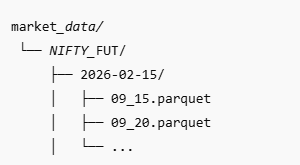

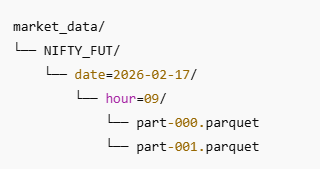

In [ ]:
# Jupyter already has an event loop
task1 = asyncio.create_task(recorder.run())
# task2 = asyncio.create_task(recorder_best.run())

{'RequestCode': 23, 'InstrumentCount': 2, 'InstrumentList': [{'ExchangeSegment': 'NSE_FNO', 'SecurityId': '51714'}, {'ExchangeSegment': 'NSE_EQ', 'SecurityId': '2885'}]}
Appended 99520 rows → market_data\NIFTY_FUT\2026-03-18\09_47.parquet
Appended 99840 rows → market_data\NIFTY_FUT\2026-03-18\09_52.parquet
Appended 99800 rows → market_data\NIFTY_FUT\2026-03-18\09_57.parquet
Appended 99960 rows → market_data\NIFTY_FUT\2026-03-18\10_02.parquet
Appended 99800 rows → market_data\NIFTY_FUT\2026-03-18\10_07.parquet
Appended 99960 rows → market_data\NIFTY_FUT\2026-03-18\10_12.parquet
Appended 99720 rows → market_data\NIFTY_FUT\2026-03-18\10_17.parquet
Appended 100040 rows → market_data\NIFTY_FUT\2026-03-18\10_22.parquet
Appended 99800 rows → market_data\NIFTY_FUT\2026-03-18\10_27.parquet
Appended 99320 rows → market_data\NIFTY_FUT\2026-03-18\10_32.parquet
Appended 99520 rows → market_data\NIFTY_FUT\2026-03-18\10_37.parquet
Appended 99640 rows → market_data\NIFTY_FUT\2026-03-18\10_42.parquet
A

In [7]:
task1

<Task finished name='Task-40' coro=<MarketRecorder.run() done, defined at c:\GIT\market_game\incremental_indexed.py:159> exception=ConnectionClosedError(None, None, None)>

In [9]:
# task1.cancel()
# await task1